# Neuronales Netz zur BTTS-Vorhersage

## Ziel

In diesem Notebook wird ein künstliches neuronales Netz entwickelt, das vorhersagen soll, ob in einem Fußballspiel beide Mannschaften mindestens ein Tor erzielen (BTTS).

Das Modell wird anschließend mit der Logistischen Regression verglichen.

Bibliotheken importieren

In [ ]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

Daten laden

In [ ]:
matches = pd.read_csv("../data/processed/btts_features.csv")

features = [
    "HomeGoalsLast5",
    "AwayGoalsLast5",
    "HomeConcededLast5",
    "AwayConcededLast5",
    "HomeFormLast5",
    "AwayFormLast5"
]

X = matches[features]
y = matches["BTTS"]

Trainings- und Testdaten

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Daten skalieren

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Neuronales Netz

In [ ]:
model = Sequential([
    Input(shape=(6,)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Modell kompilieren

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Architektur ansehen

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1 
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5289 - loss: 0.6987 - val_accuracy: 0.5184 - val_loss: 0.7013
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5457 - loss: 0.6898 - val_accuracy: 0.5050 - val_loss: 0.7035
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5624 - loss: 0.6896 - val_accuracy: 0.4983 - val_loss: 0.7046
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5398 - loss: 0.6908 - val_accuracy: 0.4816 - val_loss: 0.7044
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5641 - loss: 0.6859 - val_accuracy: 0.4849 - val_loss: 0.7060
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5641 - loss: 0.6831 - val_accuracy: 0.4816 - val_loss: 0.7065
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5633 - loss: 0.6849 - val_accuracy: 0.4582 - val_loss: 0.7074
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5666 - loss: 0.6829 - val_accuracy: 0.4849 - val_loss:

Testen des Modells aus den Testdaten

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Metriken berechnen

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5588235294117647
Precision: 0.5854430379746836
Recall : 0.8447488584474886
F1 Score : 0.6915887850467289


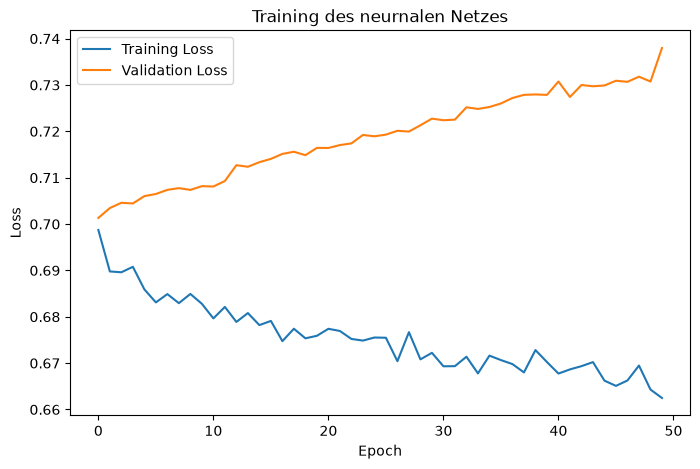

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training des neurnalen Netzes")

plt.legend()
plt.show()

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5588235294117647
Precision: 0.5854430379746836
Recall   : 0.8447488584474886
F1 Score : 0.6915887850467289


Modell und Scaler speichern

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/neural_network_v1.keras")
joblib.dump(scaler, "../models/scaler_v1.pkl")

print("Modell und Scaler gespeichert.")

Modell und Scaler gespeichert.
